# 8.1 序列模型

在上两个章节，CNN主要处理了图像这类具有空间特征的信息。本章的RNN主要是针对语言、连续数据这类具有明显序列特征的网络。下面是一些序列数据的例子：
- 预测明天的股价要比过去的股价更困难，尽管两者都只是估计一个数字。 毕竟，先见之明比事后诸葛亮难得多。 在统计学中，前者（对超出已知观测范围进行预测）称为外推法（extrapolation）， 而后者（在现有观测值之间进行估计）称为内插法（interpolation）。

- 在本质上，音乐、语音、文本和视频都是连续的。 如果它们的序列被我们重排，那么就会失去原有的意义。 比如，一个文本标题“狗咬人”远没有“人咬狗”那么令人惊讶，尽管组成两句话的字完全相同。

- 地震具有很强的相关性，即大地震发生后，很可能会有几次小余震， 这些余震的强度比非大地震后的余震要大得多。 事实上，地震是时空相关的，即余震通常发生在很短的时间跨度和很近的距离内。

## 8.1.1 统计工具

假设我们需要预测一个股票的价格，显然我们要基于已有的一次、或$t$次数据，进行下一次、或者下$k$次的预测。以根据前$t + 1$次数据预测下一次数据为例，我们要预测的是$x_t$，就通过以下途径进行：
$$
x_t \sim P(x_t \mid x_{t-1}, \ldots, x_1).
$$

### 8.1.1.1 自回归模型

“序列”听起来就像是一种“线性”，显然可以用回归模型。并可以归结为两种策略：

1. 对自己执行回归：

    - 为固定参数数量，对时间跨度为$\tau$的进行观测，并以此为数据预测。

2. 隐变量自回归：

    - 将观测总结为$h_t$，根据$h_t$预测 $\hat{x_t}$，即$\hat{x}_t = P(x_t \mid h_{t})$。并根据新的观测$h_t = g(h_{t-1}, x_{t-1})$进行总结更新。
    
    ![alt text](https://zh-v2.d2l.ai/_images/sequence-model.svg)

这两种方式都利用历史观测预测未来观测，并假设动力学（可以直观理解成计算方法）不改变。但实际上新的动力学必然受新的观测所影响，只是我们无法用目前的数据来预测新的动力学，或许之后可以找到办法进行更新。因此，对整个序列的预测实现方式为：
$$
P(x_1, \ldots, x_T) = \prod_{t=1}^T P(x_t \mid x_{t-1}, \ldots, x_1)
$$
***注**：隐变量自回归中，虽然系统的状态和记忆在更新，但本身的动力学（ $h_t = g(h_{t-1}, x_{t-1})$ 中的 $g(a,b)$ ）并没有改变*
    

## 8.1.2 训练

实践。以正弦函数为例。时间步为1k。

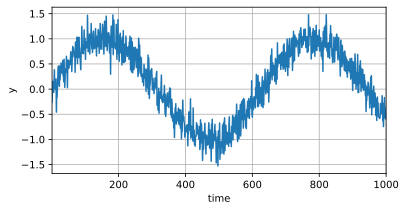

In [33]:
%matplotlib inline
import torch
from torch import nn
from d2l import torch as d2l

T = 1000
time = torch.arange(1, T + 1, dtype=torch.float32)
y = torch.sin(0.01 * time) + torch.normal(0, 0.2, size=time.shape)
d2l.plot(time, [y], 'time', 'y', xlim=[1, 1000], figsize=(6, 3))

接下来生成特征-标签对。我们设定嵌入维度 $\tau = 4$，标签为 $y_t = x_t$ ，特征为 $\mathbf{x}_t = [x_{t-\tau}, \ldots, x_{t-1}]$ 。

In [34]:
tau = 4
features = torch.zeros((T - tau, tau)) #创建一个大小为(T - tau, tau)的全零张量，用于存储特征数据。
for i in range(tau):
    features[:, i] = y[i: T - tau + i] #[:, i]表示选择features张量的所有行和第i列，并将y张量从第i个元素开始到第T - tau + i个元素的切片赋值给该列。这相当于为每个时间步创建一个长度为tau的特征向量，其中每个特征向量包含前tau个时间步的值。
labels = y[tau:].reshape((-1, 1))      # 从第tau个元素开始，创建一个新的张量labels，并将其形状调整为(-1, 1)，其中-1表示自动推断行数，1表示列数。

batch_size, n_train = 16, 600
# 只有前n_train个样本用于训练
train_iter = d2l.load_array((features[:n_train], labels[:n_train]),
                            batch_size, is_train=True)



现在特征矩阵有了，接下来就和之前感知机一模一样了。

In [35]:
# 初始化网络权重的函数
def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.xavier_uniform_(m.weight)

# 一个简单的多层感知机
def get_net():
    net = nn.Sequential(nn.Linear(4, 10),
                        nn.ReLU(),
                        nn.Linear(10, 1))
    net.apply(init_weights)
    return net

# 平方损失。注意：MSELoss计算平方误差时不带系数1/2
loss = nn.MSELoss(reduction='none')

def train(net, train_iter, loss, num_epochs, lr):
    trainer = torch.optim.Adam(net.parameters(), lr=lr)
    for epoch in range(num_epochs):
        for X, y in train_iter:
            trainer.zero_grad()
            l = loss(net(X), y)
            l.sum().backward()
            trainer.step()
        print(f'epoch {epoch + 1}, loss {l.mean():f}')


net = get_net()
train(net, train_iter, loss, 5, 0.01)

epoch 1, loss 0.025436
epoch 2, loss 0.035049
epoch 3, loss 0.052716
epoch 4, loss 0.115173
epoch 5, loss 0.061907


这是进行的单步预测。我们通过对比原图来看看在全部数据范围上预测效果。*即600之后的数据为非训练数据*

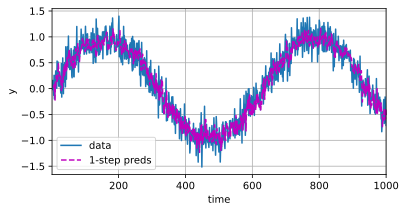

In [23]:
onestep_preds = net(features)
d2l.plot([time, time[tau:]],
         [y.detach().numpy(), onestep_preds.detach().numpy()], 'time',
         'y', legend=['data', '1-step preds'], xlim=[1, 1000],
         figsize=(6, 3))

## 8.1.3 多步预测

那么，如果是要预测一组序列数据呢？下面是从600开始，完全不依赖真实值的预测情况：

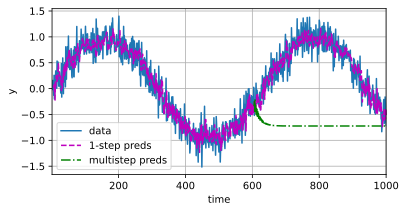

In [24]:
multistep_preds = torch.zeros(T)
multistep_preds[: n_train + tau] = y[: n_train + tau]
for i in range(n_train + tau, T): #从n_train + tau开始，迭代到T，根据自身生成的预测来进行下一步预测，逐步生成多步预测值。
    multistep_preds[i] = net(
        multistep_preds[i - tau:i].reshape((1, -1)))

d2l.plot([time, time[tau:], time[n_train + tau:]],
         [y.detach().numpy(), onestep_preds.detach().numpy(),
          multistep_preds[n_train + tau:].detach().numpy()], 'time',
         'y', legend=['data', '1-step preds', 'multistep preds'],
         xlim=[1, 1000], figsize=(6, 3))

这里是“基于预测值的预测”，并且不断延伸。由于误差会被积累，类似“复利”，于是网络几乎马上失效。

其他多步预测：

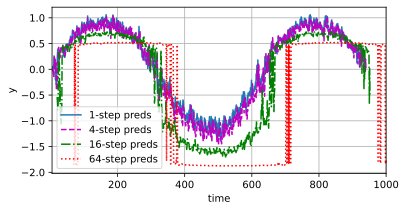

In [55]:
max_steps = 64

features = torch.zeros((T - tau - max_steps + 1, tau + max_steps))
# 列i（i<tau）是来自y的观测，其时间步从（i）到（i+T-tau-max_steps+1）
for i in range(tau):
    features[:, i] = y[i: i + T - tau - max_steps + 1] #前tau列是来自y的观测值，时间步从i到i + T - tau - max_steps + 1。这意味着每列i包含了从时间步i开始的连续观测值，直到时间步i + T - tau - max_steps + 1为止。

# 列i（i>=tau）是来自（i-tau+1）步的预测，其时间步从（i）到（i+T-tau-max_steps+1）
for i in range(tau, tau + max_steps):
    features[:, i] = net(features[:, i - tau:i]).reshape(-1)

steps = (1, 4, 16, 64)
d2l.plot([time[tau + i - 1: T - max_steps + i] for i in steps],
         [features[:, (tau + i - 1)].detach().numpy() for i in steps], 'time', 'y',
         legend=[f'{i}-step preds' for i in steps], xlim=[5, 1000],
         figsize=(6, 3))

无论任何位置，1步预测完全依据的是真实值、4步依据了一个真实值和1~3步预测值进行预测、16步依据了12~15步预测值进行预测。但是相比前一段无限依据预测的预测，“误差复利”作用有限（前一段，1步预测就依据的是预测值了）。16步的图像有点夸张。说明预测步数越大，质量越差。

## 8.1.4 尝试隐变量自回归
我想通过以下方式实现
$$
\begin{aligned}
x_t &= f(x_{t-1}, x_{t-2}, x_{t-3}, \mathbf{h_{t-1}}) \\
\mathbf{h_t}&= g(\mathbf{h_{t-1}}, x_t)
\end{aligned}
$$
其中隐变量用2维向量表示（可能表示的是是幅度、趋势等信息）

因为有两个不同机制的输出，需要两个层来完成传播。

In [75]:
class hidden_variant_regression(nn.Module):
    def __init__(self):
        super().__init__()
        # 第一层：从 [x_{t-3}, x_{t-2}, x_{t-1}, h_{t-1}] 预测 x_t
        # 输入：3个过去观测 + 4维隐状态 = 7维
        self.predict_layer = nn.Sequential(nn.Linear(5, 10), nn.ReLU(), nn.Linear(10, 1))

        # 第二层：从 [x_t, h_{t-1}] 更新隐状态
        self.hidden_layer = nn.Sequential(nn.Linear(3, 2), nn.Tanh())

    def forward(self, X, h):
        combined = torch.cat((X, h), dim=1)      # (batch_size, 7)
        x_t_pred = self.predict_layer(combined)   # (batch_size, 1)
        hidden_input = torch.cat((x_t_pred, h), dim=1)  # (batch_size, 5)
        h_t = self.hidden_layer(hidden_input)     # (batch_size, 4)
        return x_t_pred, h_t


epoch 1, loss 0.130782
epoch 2, loss 0.058120
epoch 3, loss 0.054413
epoch 4, loss 0.055337
epoch 5, loss 0.054694
epoch 6, loss 0.054753
epoch 7, loss 0.054915
epoch 8, loss 0.052400


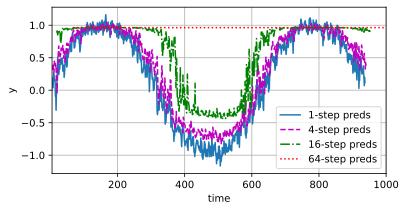

In [76]:
# 训练用样本：输入 [x_{t-3}, x_{t-2}, x_{t-1}]，标签 x_t
lag = 3
seq_features = torch.zeros((n_train - lag, lag))
seq_labels = torch.zeros((n_train - lag, 1))
for i in range(n_train - lag):
    seq_features[i] = y[i:i + lag]
    seq_labels[i] = y[i + lag]

seq_batch_size = 16
seq_train_iter = d2l.load_array((seq_features, seq_labels), seq_batch_size, is_train=True)

net_hidden = hidden_variant_regression()

def train_hidden_rnn(net, train_iter, loss_fn, num_epochs, lr):
    trainer = torch.optim.Adam(net.parameters(), lr=lr)
    for epoch in range(num_epochs):
        epoch_loss = 0.0
        nb = 0
        for X, y_label in train_iter:
            h = torch.zeros(X.shape[0], 2)
            x_pred, h = net(X, h)
            loss = loss_fn(x_pred, y_label)
            trainer.zero_grad()
            loss.backward()
            trainer.step()
            epoch_loss += loss.detach().item()
            nb += 1
        print(f'epoch {epoch + 1}, loss {epoch_loss / nb:.6f}')

loss_fn_hidden = nn.MSELoss()
train_hidden_rnn(net_hidden, seq_train_iter, loss_fn_hidden, 8, 0.01)


max_steps_hidden = 64
hidden_features = torch.zeros((T - lag - max_steps_hidden + 1, lag + max_steps_hidden))

# 前 lag 列用真实观测值填充
for i in range(lag):
    hidden_features[:, i] = y[i: i + T - lag - max_steps_hidden + 1]

# 递推预测列：维护每一行样本的隐状态
net_hidden.eval()
h_all = torch.zeros(hidden_features.shape[0], 2)
with torch.no_grad():
    for i in range(lag, lag + max_steps_hidden):
        x_in = hidden_features[:, i - lag:i]
        x_pred, h_all = net_hidden(x_in, h_all)
        hidden_features[:, i] = x_pred.reshape(-1)
net_hidden.train()

d2l.plot([time[lag + i - 1: T - max_steps_hidden + i] for i in steps],
         [hidden_features[:, (lag + i - 1)].detach().numpy() for i in steps],
         'time', 'y', legend=[f'{i}-step preds' for i in steps],
         xlim=[5, 1000], figsize=(6, 3))


额，看来不怎么好用。